In [31]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.feature_selection import mutual_info_regression

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

In [32]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

In [33]:
# Load your dataset
df = pd.read_csv('../data/features/features_complete.csv')
print(f"Dataset shape: {df.shape}")

# ---------------------------
# Step 1: Select numeric features
# ---------------------------
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude target & other unwanted columns
exclude_cols = ['views', 'likes', 'dislikes', 'comment_count']
feature_cols = [col for col in numeric_features if col not in exclude_cols]

print(f"Total numeric features available: {len(feature_cols)}")
print(feature_cols)


Dataset shape: (55886, 40)
Total numeric features available: 18
['index', 'category_id', 'hour_of_trending', 'days_until_trending', 'title_length', 'uppercase_words', 'contains_numbers_or_emojis', 'num_emojis', 'has_emoji', 'sentiment_polarity', 'sentiment_subjectivity', 'top50_pca1', 'top50_pca2', 'top50_pca3', 'published_day_of_week_num', 'title_word_count', 'has_question', 'is_clickbait']


In [34]:
# ---------------------------
# Step 2: Pearson Correlation with target
# ---------------------------
correlations = []
for feature in feature_cols:
    valid_data = df[[feature, 'views']].dropna()
    if len(valid_data) > 0:
        corr, p_value = pearsonr(valid_data[feature], valid_data['views'])
        correlations.append({
            'feature': feature,
            'correlation': corr,
            'abs_correlation': abs(corr),
            'p_value': p_value,
            'significant': p_value < 0.05
        })

corr_df = pd.DataFrame(correlations).sort_values('abs_correlation', ascending=False)
print("\nTop 10 features by absolute correlation:")
print(corr_df.head(10))


Top 10 features by absolute correlation:
                       feature  correlation  abs_correlation        p_value  \
12                  top50_pca2    -0.181958         0.181958   0.000000e+00   
8                    has_emoji    -0.164805         0.164805   0.000000e+00   
10      sentiment_subjectivity     0.156914         0.156914  6.377798e-305   
6   contains_numbers_or_emojis    -0.111524         0.111524  3.999956e-154   
0                        index    -0.091936         0.091936  3.634240e-105   
5              uppercase_words    -0.080757         0.080757   1.661504e-81   
7                   num_emojis    -0.076718         0.076718   1.019262e-73   
2             hour_of_trending    -0.061540         0.061540   4.925612e-48   
13                  top50_pca3     0.051452         0.051452   4.430248e-34   
1                  category_id    -0.041867         0.041867   4.093623e-23   

    significant  
12         True  
8          True  
10         True  
6          True 

In [35]:
correlations = []
for feature in feature_cols:
    valid_data = df[[feature, 'views']].dropna()
    if len(valid_data) > 0:
        corr, p_value = pearsonr(valid_data[feature], valid_data['views'])
        correlations.append({
            'feature': feature,
            'correlation': corr,
            'abs_correlation': abs(corr),
            'p_value': p_value,
            'significant': p_value < 0.05
        })

corr_df = pd.DataFrame(correlations).sort_values('abs_correlation', ascending=False)
print("\nTop 10 most important features based on correlation:")
print(corr_df.head(10))



Top 10 most important features based on correlation:
                       feature  correlation  abs_correlation        p_value  \
12                  top50_pca2    -0.181958         0.181958   0.000000e+00   
8                    has_emoji    -0.164805         0.164805   0.000000e+00   
10      sentiment_subjectivity     0.156914         0.156914  6.377798e-305   
6   contains_numbers_or_emojis    -0.111524         0.111524  3.999956e-154   
0                        index    -0.091936         0.091936  3.634240e-105   
5              uppercase_words    -0.080757         0.080757   1.661504e-81   
7                   num_emojis    -0.076718         0.076718   1.019262e-73   
2             hour_of_trending    -0.061540         0.061540   4.925612e-48   
13                  top50_pca3     0.051452         0.051452   4.430248e-34   
1                  category_id    -0.041867         0.041867   4.093623e-23   

    significant  
12         True  
8          True  
10         True  
6   

In [36]:
# ---------------------------
# Step 3: Mutual Information (nonlinear importance)
# ---------------------------
mi = mutual_info_regression(df[feature_cols].fillna(0), df['views'])
mi_df = pd.DataFrame({'feature': feature_cols, 'mutual_info': mi})
mi_df = mi_df.sort_values('mutual_info', ascending=False)
print("\nTop 10 features by Mutual Information:")
print(mi_df.head(10))



Top 10 features by Mutual Information:
                   feature  mutual_info
0                    index     0.201709
13              top50_pca3     0.054730
12              top50_pca2     0.054178
11              top50_pca1     0.051248
1              category_id     0.050664
9       sentiment_polarity     0.036639
10  sentiment_subjectivity     0.034218
7               num_emojis     0.032321
4             title_length     0.026863
3      days_until_trending     0.026741


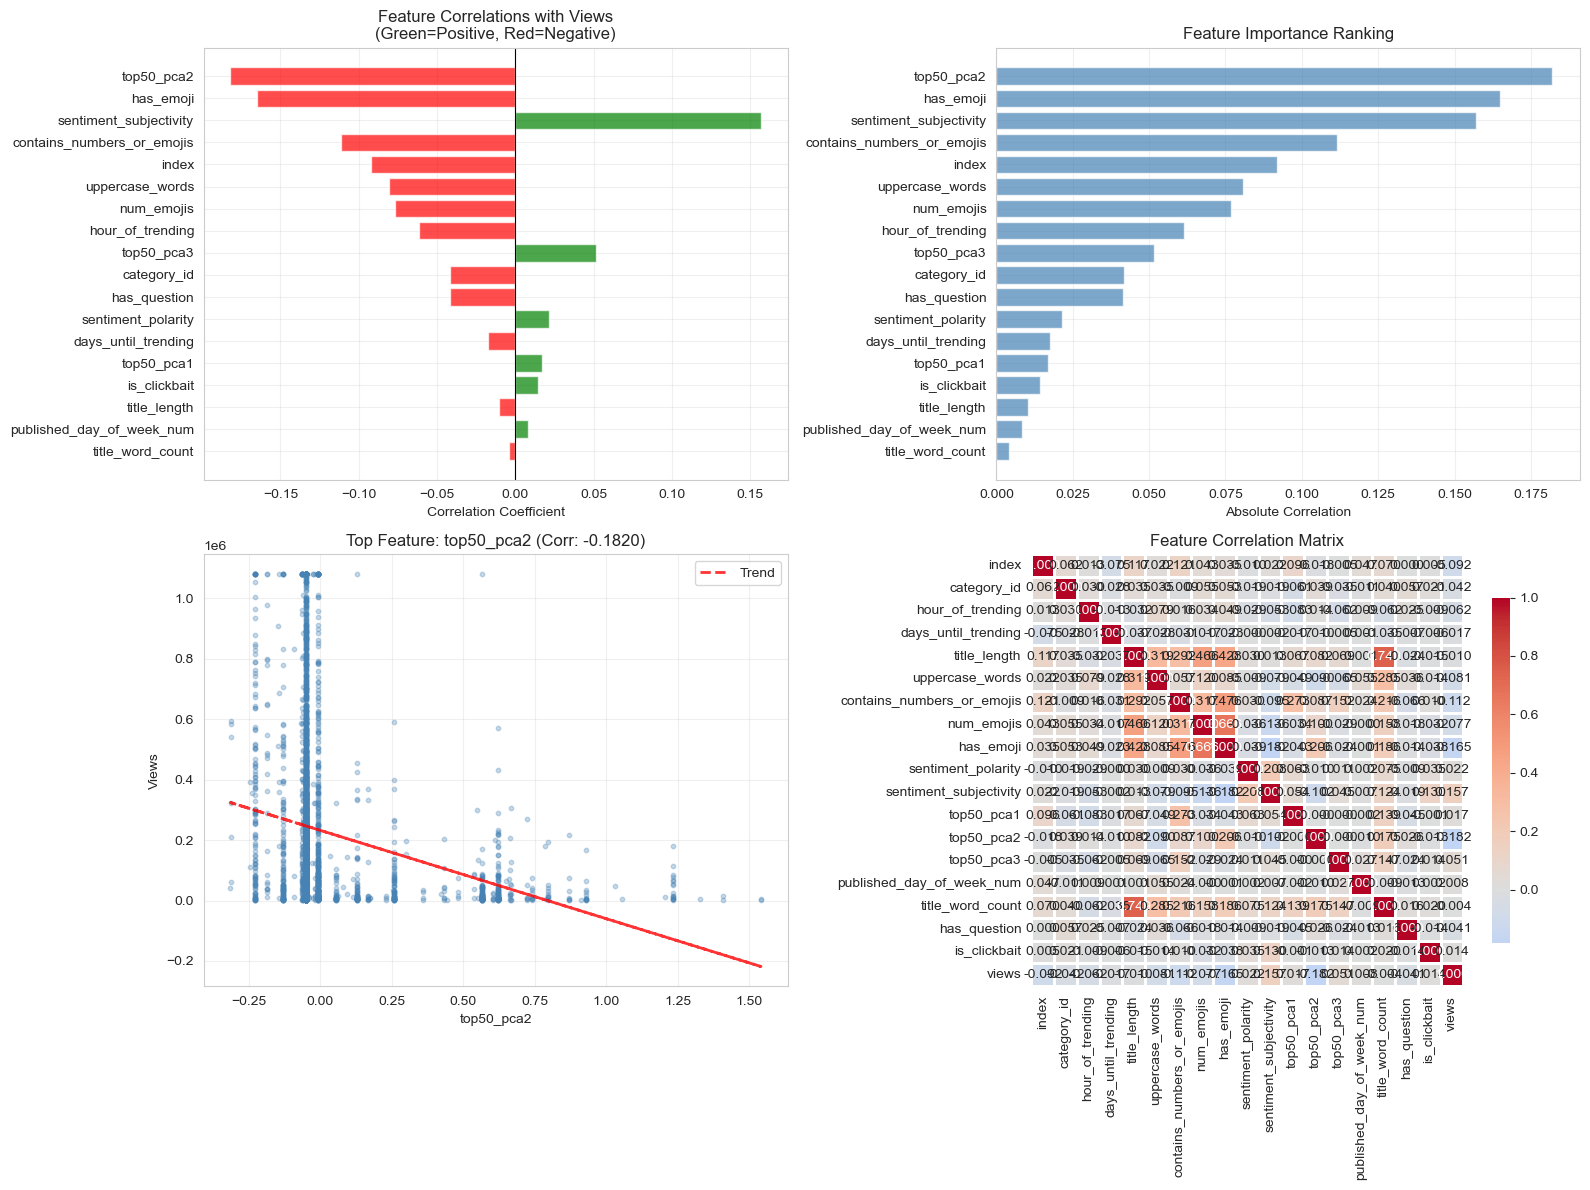

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Correlation Bar Chart
ax = axes[0, 0]
colors = ['green' if x > 0 else 'red' for x in corr_df['correlation']]
ax.barh(range(len(corr_df)), corr_df['correlation'], color=colors, alpha=0.7)
ax.set_yticks(range(len(corr_df)))
ax.set_yticklabels(corr_df['feature'])
ax.set_xlabel('Correlation Coefficient')
ax.set_title('Feature Correlations with Views\n(Green=Positive, Red=Negative)')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.invert_yaxis()
ax.grid(True, alpha=0.3)

# Plot 2: Absolute Correlation (Importance)
ax = axes[0, 1]
ax.barh(range(len(corr_df)), corr_df['abs_correlation'], color='steelblue', alpha=0.7)
ax.set_yticks(range(len(corr_df)))
ax.set_yticklabels(corr_df['feature'])
ax.set_xlabel('Absolute Correlation')
ax.set_title('Feature Importance Ranking')
ax.invert_yaxis()
ax.grid(True, alpha=0.3)

# Plot 3: Scatter of top feature
if len(corr_df) > 0:
    top_feature = corr_df.iloc[0]['feature']
    ax = axes[1, 0]
    sample_df = df.sample(min(5000, len(df)), random_state=42)
    ax.scatter(sample_df[top_feature], sample_df['views'], alpha=0.3, s=10, color='steelblue')
    ax.set_xlabel(top_feature)
    ax.set_ylabel('Views')
    ax.set_title(f'Top Feature: {top_feature} (Corr: {corr_df.iloc[0]["correlation"]:.4f})')
    
    # Trend line
    z = np.polyfit(sample_df[top_feature].fillna(0), sample_df['views'], 1)
    p = np.poly1d(z)
    ax.plot(sample_df[top_feature].fillna(0), p(sample_df[top_feature].fillna(0)), "r--", linewidth=2, alpha=0.8, label='Trend')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Plot 4: Correlation Heatmap
ax = axes[1, 1]
heatmap_cols = feature_cols + ['views']
corr_matrix = df[heatmap_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, square=True, linewidths=1, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.savefig('../reports/features/feature_importance_analysis_auto.png', dpi=300, bbox_inches='tight')
plt.show()

In [38]:
# ---------------------------
# Step 5: Summary report
# ---------------------------
print("\n🎯 FEATURE IMPORTANCE SUMMARY")
print("="*70)

# Positive and negative correlations
positive_corr = corr_df[corr_df['correlation'] > 0]
negative_corr = corr_df[corr_df['correlation'] < 0]
weak_corr = corr_df.nsmallest(3, 'abs_correlation')

print("\nTop positively correlated features with views:")
for _, row in positive_corr.head(10).iterrows():
    print(f"   • {row['feature']:30s} | +{row['correlation']:.4f}")

print("\nTop negatively correlated features with views:")
for _, row in negative_corr.head(10).iterrows():
    print(f"   • {row['feature']:30s} | {row['correlation']:.4f}")

print("\nFeatures with weak correlation:")
for _, row in weak_corr.iterrows():
    print(f"   • {row['feature']:30s} | {row['correlation']:.4f}")

# Recommend keeping strong features
strong_features = corr_df[corr_df['abs_correlation'] > 0.01]['feature'].tolist()
weak_features = corr_df[corr_df['abs_correlation'] <= 0.01]['feature'].tolist()

print("\nRecommended for ML model:")
print(f"✓ Keep these features (strong correlation): {strong_features}")
if weak_features:
    print(f"✗ Consider dropping (weak correlation): {weak_features}")


🎯 FEATURE IMPORTANCE SUMMARY

Top positively correlated features with views:
   • sentiment_subjectivity         | +0.1569
   • top50_pca3                     | +0.0515
   • sentiment_polarity             | +0.0215
   • top50_pca1                     | +0.0170
   • is_clickbait                   | +0.0143
   • published_day_of_week_num      | +0.0084

Top negatively correlated features with views:
   • top50_pca2                     | -0.1820
   • has_emoji                      | -0.1648
   • contains_numbers_or_emojis     | -0.1115
   • index                          | -0.0919
   • uppercase_words                | -0.0808
   • num_emojis                     | -0.0767
   • hour_of_trending               | -0.0615
   • category_id                    | -0.0419
   • has_question                   | -0.0414
   • days_until_trending            | -0.0175

Features with weak correlation:
   • title_word_count               | -0.0043
   • published_day_of_week_num      | 0.0084
   • title_len